In [2]:
import zipfile
import os

In [3]:

zip_path = "archive (1).zip"
extract_dir = "extracted_files"

os.makedirs(extract_dir, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

csv_files = [f for f in os.listdir(extract_dir) if f.endswith(".csv")]
print("CSV files found:")
for f in csv_files:
    print(f)


CSV files found:
youtube_channel_info_v1.csv
youtube_channel_info_v2.csv


In [4]:
import  pandas as pd
extract_dir ='extracted_files'


csv_files =[ f for f in os.listdir(extract_dir) if f. endswith(".csv")]
df = pd.read_csv(os.path.join(extract_dir, csv_files[0]))

df.head()

,channel_name,channel_id,view_count,category,country,defaultLanguage,subscriber_count,created_date,description,custom_url,thumbnail,video_count
0,BLACKPINK,UCOmHUn--16B90oW2L6FRR3A,39962585446,"https://en.wikipedia.org/wiki/Music_of_Asia, h...",KR,NaN,99000000,2016-06-29T03:15:23Z,BLACKPINK Official YouTube Channel 블랙핑크 공식 유튜브...,@blackpink,https://yt3.ggpht.com/U3VrCkKjzTpQ3VYv4SCPjNfD...,636
1,HYBE LABELS,UC3IZKseVpdzPSBaWxBxundA,41604896923,"https://en.wikipedia.org/wiki/Hip_hop_music, h...",KR,NaN,78700000,2008-06-04T08:23:22Z,Welcome to the official YouTube channel of HYB...,@hybelabels,https://yt3.ggpht.com/ytc/AIdro_l8g0yRFG8xoe_q...,2817
2,music,UCh7X3QOvvDgBNB80_ILrl9Q,66488,"https://en.wikipedia.org/wiki/Technology, http...",NaN,NaN,179,2017-11-17T05:53:19Z,NaN,@music-lw4ez,https://yt3.ggpht.com/ytc/AIdro_k9GtyIisxdF4aU...,107
3,#SPORTS,UCOtDOEFXsAHu0LTfK1Dejqw,31186,"https://en.wikipedia.org/wiki/Action_game, htt...",NaN,NaN,37,2015-04-03T12:22:45Z,Welcome to one of the most beautiful channel o...,@sports-se7qn,https://yt3.ggpht.com/ytc/AIdro_lbN2EYYIH4TBth...,512
4,BILLIE EILISH,UCVNE660NcgYzi18LwwUZb7Q,14316364,NaN,NaN,NaN,82300,2019-01-18T05:14:32Z,NaN,@billieeilish8477,https://yt3.ggpht.com/ytc/AIdro_n3NfvUAVtcUJvW...,1


In [5]:
df.head()

missing_values = df.isnull().sum
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
<bound method DataFrame.sum of       channel_name  channel_id  view_count  category  country  \
0            False       False       False     False    False   
1            False       False       False     False    False   
2            False       False       False     False     True   
3            False       False       False     False     True   
4            False       False       False      True     True   
...            ...         ...         ...       ...      ...   
9898         False       False       False     False    False   
9899         False       False       False     False    False   
9900         False       False       False     False    False   
9901         False       False       False     False    False   
9902         False       False       False     False    False   

      defaultLanguage  subscriber_count  created_date  description  \
0                True             False         False        False   
1                

In [6]:
if 'created_date' in df.columns:
    try:
        df['created_date'] = pd.to_datetime(df['created_date'], infer_datetime_format=True)
        print('created_date column successfully converted to datetime')
    except Exception as e:
        print(f'error converting created_date column: {e}')

df.info()


error converting created_date column: time data "2021-05-22T10:18:55.864442Z" doesn't match format "%Y-%m-%dT%H:%M:%S%z", at position 12. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9903 entries, 0 to 9902
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   channel_name      9903 non-null   object
 1   channel_id        9903 non-null   object
 2   view_count        9903 non-null   int64 
 3   category          9744 non-null   object
 4   country           8347 non-null   object
 5   defaultLanguage   1087 non-null   object
 6   subscriber_count  9903 non-null   int

/tmp/ipykernel_5366/1504690196.py:3: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['created_date'] = pd.to_datetime(df['created_date'], infer_datetime_format=True)


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns



In [8]:
most_viewed = df.loc[df['view_count'].idxmax()]
print("Most viewed YouTube channel:")
print(most_viewed[['channel_name', 'view_count', 'subscriber_count', 'category', 'country']])


Most viewed YouTube channel:
channel_name                               Cocomelon - Nursery Rhymes
view_count                                               210297046845
subscriber_count                                            198000000
category            https://en.wikipedia.org/wiki/Music, https://e...
country                                                            US
Name: 46, dtype: object


                   channel_name    view_count  subscriber_count  \
46   Cocomelon - Nursery Rhymes  210297046845         198000000   
13                    SET India  182199562821         187000000   
32                     Sony SAB  135105347405         104000000   
743           ✿ Kids Diana Show  119473824936         137000000   
36                  Like Nastya  116624139968         130000000   
31                Vlad and Niki  113149275959         146000000   
21                       Zee TV  108790970358          95100000   
82              Toys and Colors  107170591777          79900000   
41                          WWE   98591530693         111000000   
9                       MrBeast   96708625401         443000000   

                                              category country  
46   https://en.wikipedia.org/wiki/Music, https://e...      US  
13   https://en.wikipedia.org/wiki/Entertainment, h...      IN  
32   https://en.wikipedia.org/wiki/Humour, https://...      IN  
74

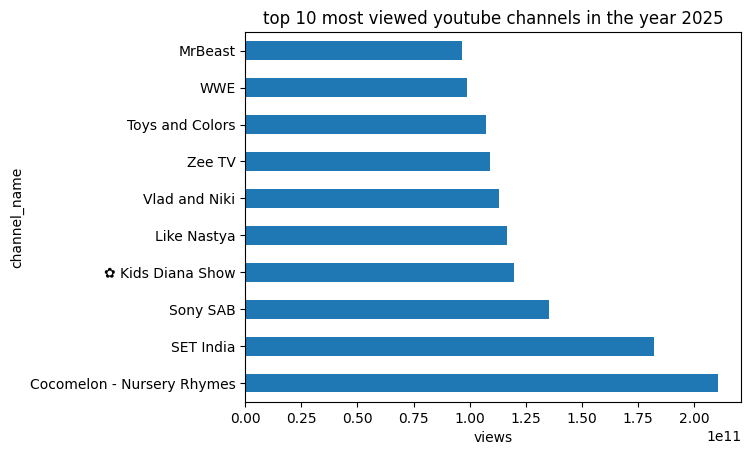

In [9]:
top10 = df.nlargest(10, 'view_count')[['channel_name', 'view_count', 'subscriber_count', 'category', 'country']]
print(top10)

top10.plot (
    kind ='barh',
    x ='channel_name',
    y ='view_count',
    title="top 10 most viewed youtube channels in the year 2025",
    legend= False,

)
plt.xlabel('views')
plt.show();

In [10]:
top_subs = df.nlargest(10, 'subscriber_count')[['channel_name', 'subscriber_count', 'view_count', 'category', 'country']]
print("Top 10 channels by subscribers:")
print(top_subs)

Top 10 channels by subscribers:
                   channel_name  subscriber_count    view_count  \
9                       MrBeast         443000000   96708625401   
46   Cocomelon - Nursery Rhymes         198000000  210297046845   
13                    SET India         187000000  182199562821   
31                Vlad and Niki         146000000  113149275959   
743           ✿ Kids Diana Show         137000000  119473824936   
36                  Like Nastya         130000000  116624139968   
41                          WWE         111000000   98591530693   
44                    PewDiePie         110000000   29412236943   
32                     Sony SAB         104000000  135105347405   
0                     BLACKPINK          99000000   39962585446   

                                              category country  
9    https://en.wikipedia.org/wiki/Lifestyle_(socio...      US  
46   https://en.wikipedia.org/wiki/Music, https://e...      US  
13   https://en.wikipedia.org/wiki/

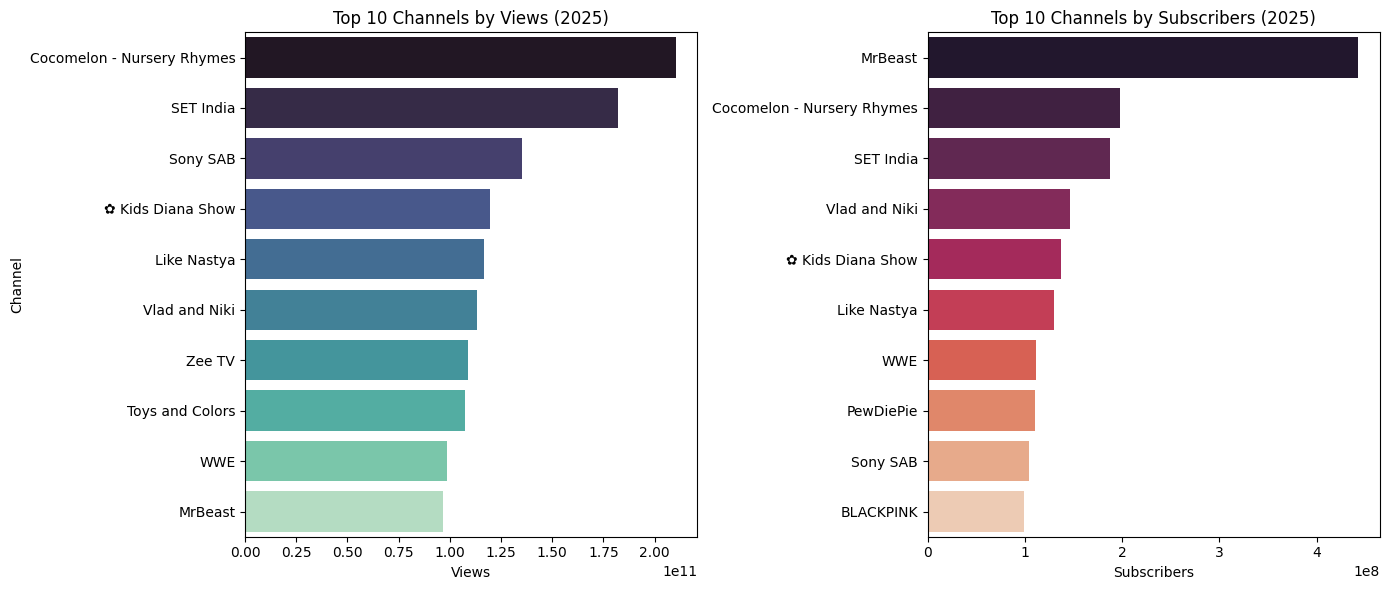

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_views = df.nlargest(10, 'view_count')
sns.barplot(
    data=top_views,
    y='channel_name',
    x='view_count',
    hue='channel_name',     # <-- added hue
    palette='mako',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Top 10 Channels by Views (2025)')
axes[0].set_xlabel('Views')
axes[0].set_ylabel('Channel')

top_subs = df.nlargest(10, 'subscriber_count')
sns.barplot(
    data=top_subs,
    y='channel_name',
    x='subscriber_count',
    hue='channel_name',     # <-- added hue
    palette='rocket',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Top 10 Channels by Subscribers (2025)')
axes[1].set_xlabel('Subscribers')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show();

In [12]:

df['subs_per_video'] = df['subscriber_count'] / df['video_count']


In [13]:
df[['channel_name', 'subscriber_count', 'video_count', 'subs_per_video']].head(10)


,channel_name,subscriber_count,video_count,subs_per_video
0,BLACKPINK,99000000,636,155660.377358
1,HYBE LABELS,78700000,2817,27937.522187
2,music,179,107,1.672897
3,#SPORTS,37,512,0.072266
4,BILLIE EILISH,82300,1,82300.000000
5,Shemaroo,60400000,13374,4516.225512
6,JuegaGerman,54200000,2368,22888.513514
7,LooLoo Kids - Nursery Rhymes and Children's Songs,61000000,1051,58039.961941
8,Tips Official,79100000,8639,9156.152332
9,MrBeast,443000000,906,488962.472406


In [14]:
df.sort_values('subs_per_video', ascending=False)[['channel_name', 'subscriber_count', 'video_count', 'subs_per_video']].head(10)


,channel_name,subscriber_count,video_count,subs_per_video
730,NollywoodStreams,4470000,0,inf
735,Daniel Pérez,3,0,inf
1530,Kate Kh.,53,0,inf
9170,Sabrina Koun,138000,0,inf
7261,funnyplox,6110000,0,inf
1554,soyfredy,2,0,inf
752,mikeltube,67,0,inf
6188,FAMILY BOOMS,16800000,0,inf
760,creativekids,9,0,inf
789,armoo,1,0,inf


/tmp/ipykernel_5366/1506340097.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='coolwarm')


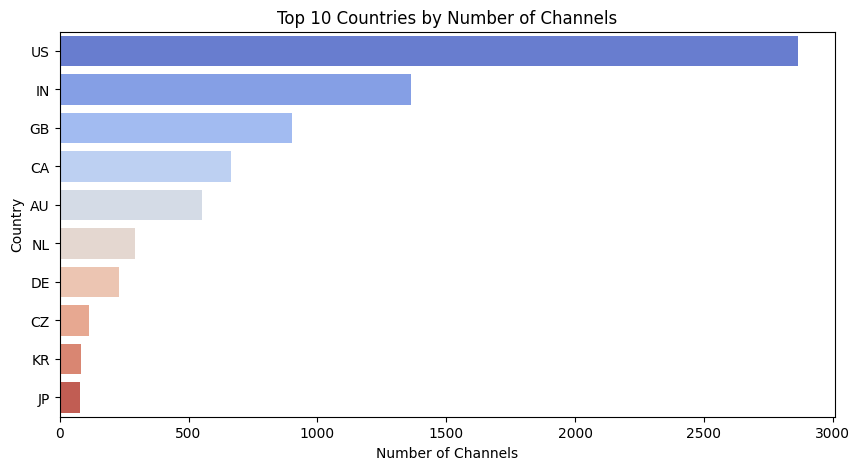

/tmp/ipykernel_5366/1506340097.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='flare')


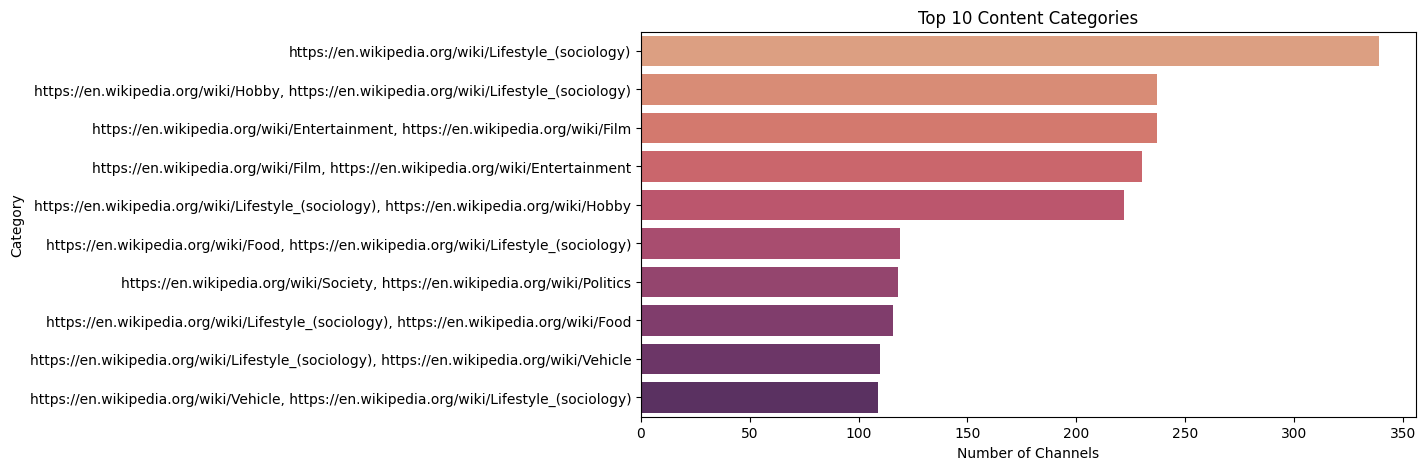

In [15]:
if 'country' in df.columns:
    top_countries = df['country'].value_counts().head(10)
    plt.figure(figsize=(10,5))
    sns.barplot(x=top_countries.values, y=top_countries.index, palette='coolwarm')
    plt.title('Top 10 Countries by Number of Channels')
    plt.xlabel('Number of Channels')
    plt.ylabel('Country')
    plt.show()

if 'category' in df.columns:
    top_categories = df['category'].value_counts().head(10)
    plt.figure(figsize=(10,5))
    sns.barplot(x=top_categories.values, y=top_categories.index, palette='flare')
    plt.title('Top 10 Content Categories')
    plt.xlabel('Number of Channels')
    plt.ylabel('Category')
    plt.show()


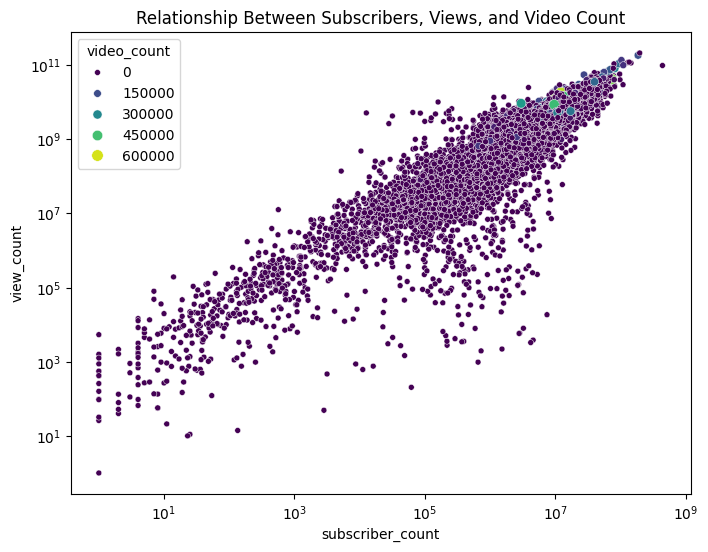

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='subscriber_count',
    y='view_count',
    hue='video_count',
    size='video_count',
    palette='viridis',
)
plt.title('Relationship Between Subscribers, Views, and Video Count')
plt.xscale('log')
plt.yscale('log')
plt.show()


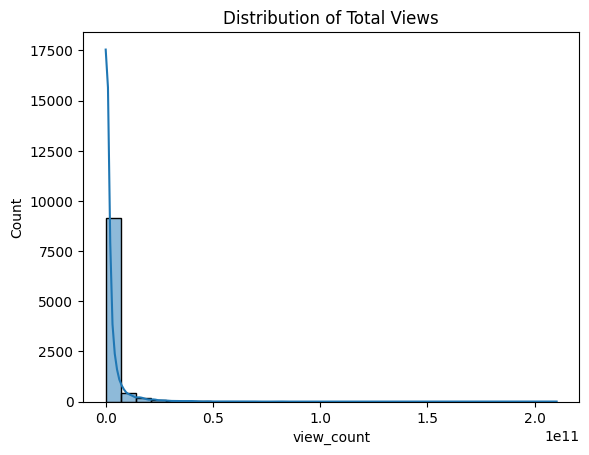

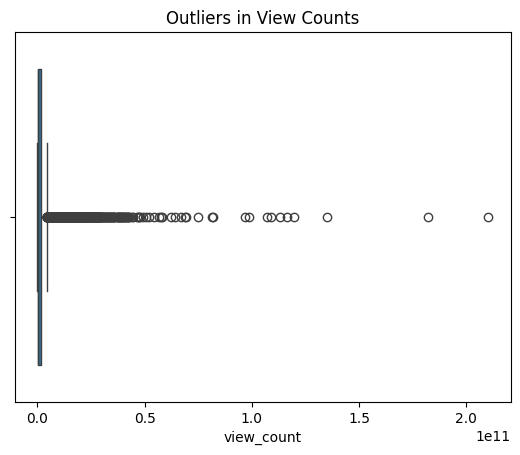

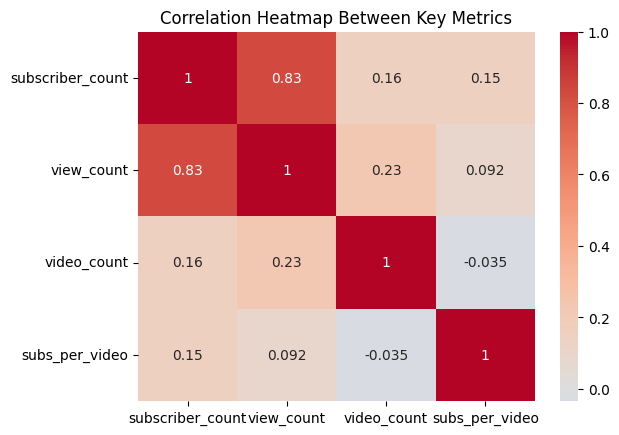

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Distribution of Views
sns.histplot(df['view_count'], bins=30, kde=True)
plt.title("Distribution of Total Views")
plt.show()

# 2️⃣ Outliers (boxplot)
sns.boxplot(x=df['view_count'])
plt.title("Outliers in View Counts")
plt.show()

# 3️⃣ Correlation between key metrics
corr = df[['subscriber_count', 'view_count', 'video_count', 'subs_per_video']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap Between Key Metrics")
plt.show()


In [19]:
from scipy import stats

# Create size categories
df['size_group'] = pd.qcut(df['subscriber_count'], 3, labels=['Small', 'Medium', 'Large'])

# Run ANOVA on view_count across these groups
anova = stats.f_oneway(
    df[df['size_group'] == 'Small']['view_count'],
    df[df['size_group'] == 'Medium']['view_count'],
    df[df['size_group'] == 'Large']['view_count']
)
print("ANOVA F-statistic:", anova.statistic)
print("p-value:", anova.pvalue)


ANOVA F-statistic: 931.0657252598512
p-value: 0.0


In [20]:
from scipy.stats import kruskal

kruskal_test = kruskal(
    df[df['size_group'] == 'Small']['view_count'],
    df[df['size_group'] == 'Medium']['view_count'],
    df[df['size_group'] == 'Large']['view_count']
)
print("Kruskal H-statistic:", kruskal_test.statistic)
print("p-value:", kruskal_test.pvalue)


Kruskal H-statistic: 6726.461083423119
p-value: 0.0
